# Heart Disease Risk Analysis
**Dataset:** `heart_disease_risk_2026.csv` — 9,001 patients, 26 features, binary target (`has_heart_disease`)

**Central question:** Do lifestyle features (steps, sleep, stress, diet, exercise) add genuine predictive power beyond clinical labs alone?

> ⚠️ **Disclaimer:** This dataset is synthetic. No findings should be interpreted as medical advice or used for diagnostic purposes.


## 0 · Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

import xgboost as xgb
import shap

# ── Global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
SEED = 42


In [2]:
df = pd.read_csv('heart_disease_risk_2026.csv')
print(f'Shape: {df.shape}')
print(f'\nMissing values: {df.isnull().sum().sum()} total')
print(f'Duplicates: {df.duplicated().sum()}')
df.head(3)


Shape: (9000, 27)

Missing values: 0 total
Duplicates: 0


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
patient_id,9000.0,4500.50,2598.22,1.0,2250.75,4500.5,6750.25,9000.0
age,9000.0,53.98,13.01,18.0,45.00,54.0,63.00,90.0
resting_bp_systolic,9000.0,127.85,13.77,85.0,119.00,128.0,137.00,181.0
resting_bp_diastolic,9000.0,80.79,10.94,50.0,74.00,81.0,88.00,126.0
cholesterol_total,9000.0,188.75,32.27,90.0,167.00,189.0,211.00,314.0
hdl,9000.0,55.22,12.39,18.0,47.00,55.0,64.00,110.0
ldl,9000.0,103.28,27.34,35.0,85.00,103.0,122.00,207.0
triglycerides,9000.0,152.04,51.45,35.0,117.00,151.0,186.00,390.0
fasting_blood_sugar,9000.0,119.47,22.78,60.0,104.00,119.0,135.00,204.0
hba1c,9000.0,5.79,0.69,4.0,5.30,5.8,6.30,8.6


## 1 · Exploratory Data Analysis

### 1.1 Class Balance

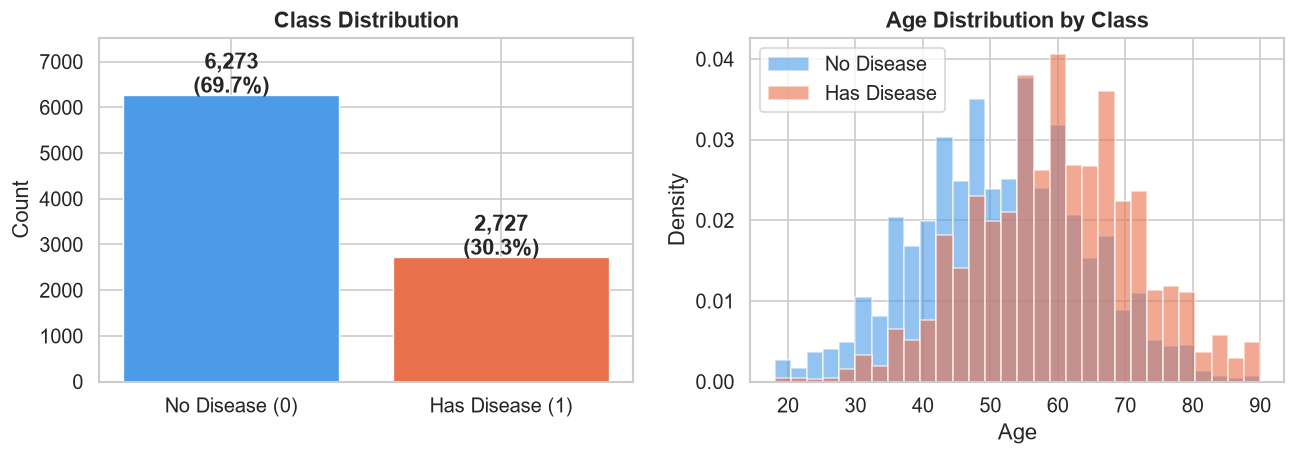

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['has_heart_disease'].value_counts()
axes[0].bar(['No Disease (0)', 'Has Disease (1)'], counts.values,
            color=['#4C9BE8', '#E8714C'], edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) * 1.2)

for label, colour, name in zip([0, 1], ['#4C9BE8', '#E8714C'], ['No Disease', 'Has Disease']):
    axes[1].hist(df[df['has_heart_disease'] == label]['age'], bins=30,
                 alpha=0.6, color=colour, label=name, density=True)
axes[1].set_title('Age Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()


### 1.2 Correlation with Target

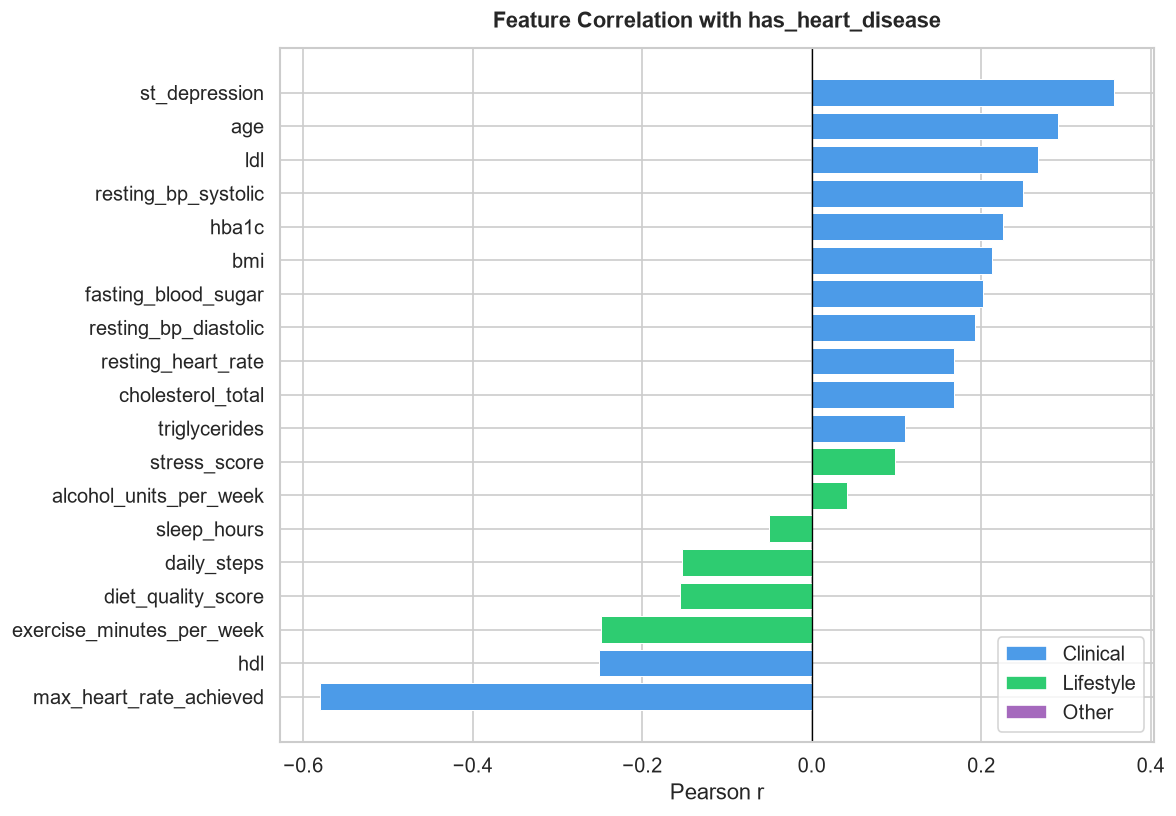

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop(['patient_id', 'has_heart_disease'])
corrs = df[numeric_cols].corrwith(df['has_heart_disease']).sort_values()

clinical  = ['resting_bp_systolic','resting_bp_diastolic','cholesterol_total','hdl','ldl',
             'triglycerides','fasting_blood_sugar','hba1c','bmi','resting_heart_rate',
             'max_heart_rate_achieved','st_depression','age']
lifestyle = ['exercise_minutes_per_week','sleep_hours','stress_score','daily_steps',
             'diet_quality_score','alcohol_units_per_week']

colours = ['#4C9BE8' if c in clinical else '#2ECC71' if c in lifestyle else '#A569BD'
           for c in corrs.index]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(corrs.index, corrs.values, color=colours, edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with has_heart_disease', fontweight='bold', pad=12)
ax.set_xlabel('Pearson r')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C9BE8', label='Clinical'),
                   Patch(facecolor='#2ECC71', label='Lifestyle'),
                   Patch(facecolor='#A569BD', label='Other')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()


### 1.3 Targeted EDA Questions

#### Q1 — Does `stress_score` / `sleep_hours` predict risk independently of BP & cholesterol?

In [6]:
from scipy.stats import pearsonr

def partial_corr(df, x, y, controls):
    """Partial correlation of x~y, partialling out controls via linear residualisation."""
    cols = [x, y] + controls
    sub = df[cols].dropna()
    def residualise(target, predictors):
        X = np.column_stack([np.ones(len(sub))] + [sub[p] for p in predictors])
        betas = np.linalg.lstsq(X, sub[target], rcond=None)[0]
        return sub[target].values - X @ betas
    rx = residualise(x, controls)
    ry = residualise(y, controls)
    r, p = pearsonr(rx, ry)
    return round(float(r), 4), round(float(p), 6)

controls = ['resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'ldl', 'hba1c']

results = {}
for feat in ['stress_score', 'sleep_hours', 'diet_quality_score', 'daily_steps', 'exercise_minutes_per_week']:
    r, p = partial_corr(df, feat, 'has_heart_disease', controls)
    results[feat] = {'partial_r': r, 'p_value': p, 'significant (p<0.05)': p < 0.05}

partial_df = pd.DataFrame(results).T
print("Partial correlations with has_heart_disease (controlling for clinical labs):\n")
print(partial_df.to_string())


Partial correlations with has_heart_disease (controlling for clinical labs):

                          partial_r   p_value significant (p<0.05)
stress_score                 0.0629       0.0                 True
sleep_hours                 -0.0502  0.000002                 True
diet_quality_score          -0.0985       0.0                 True
daily_steps                 -0.1123       0.0                 True
exercise_minutes_per_week   -0.1592       0.0                 True


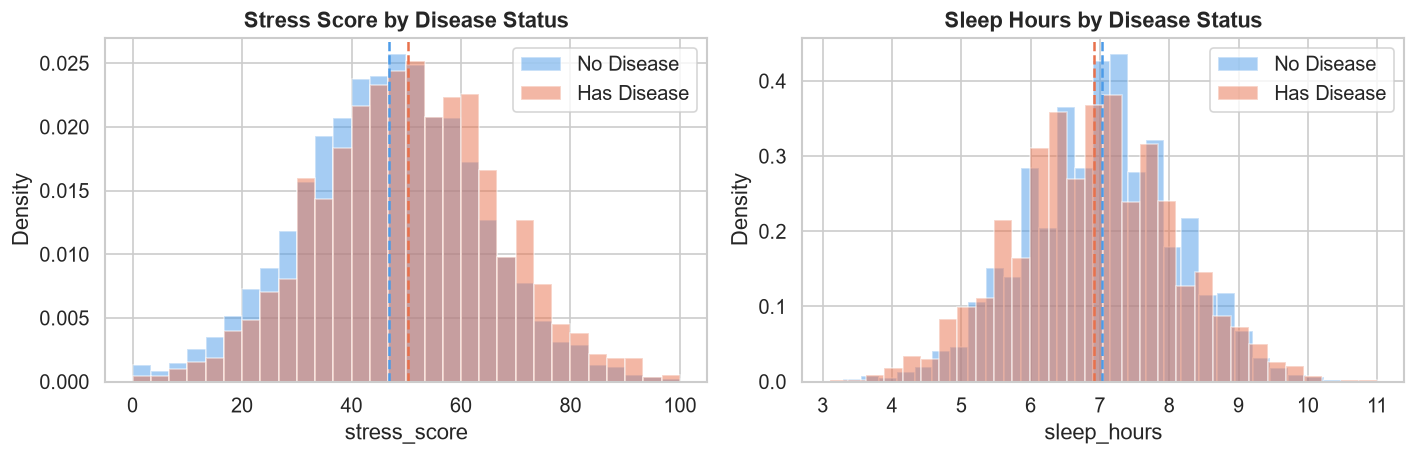

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, title in zip(axes,
                            ['stress_score', 'sleep_hours'],
                            ['Stress Score', 'Sleep Hours']):
    for label, colour, name in zip([0, 1], ['#4C9BE8', '#E8714C'], ['No Disease', 'Has Disease']):
        data = df[df['has_heart_disease'] == label][feat]
        ax.hist(data, bins=30, alpha=0.5, color=colour, label=name, density=True)
        ax.axvline(data.mean(), color=colour, linestyle='--', linewidth=1.5)
    ax.set_title(f'{title} by Disease Status', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()


#### Q2 — Do wearable owners differ in activity / sleep?

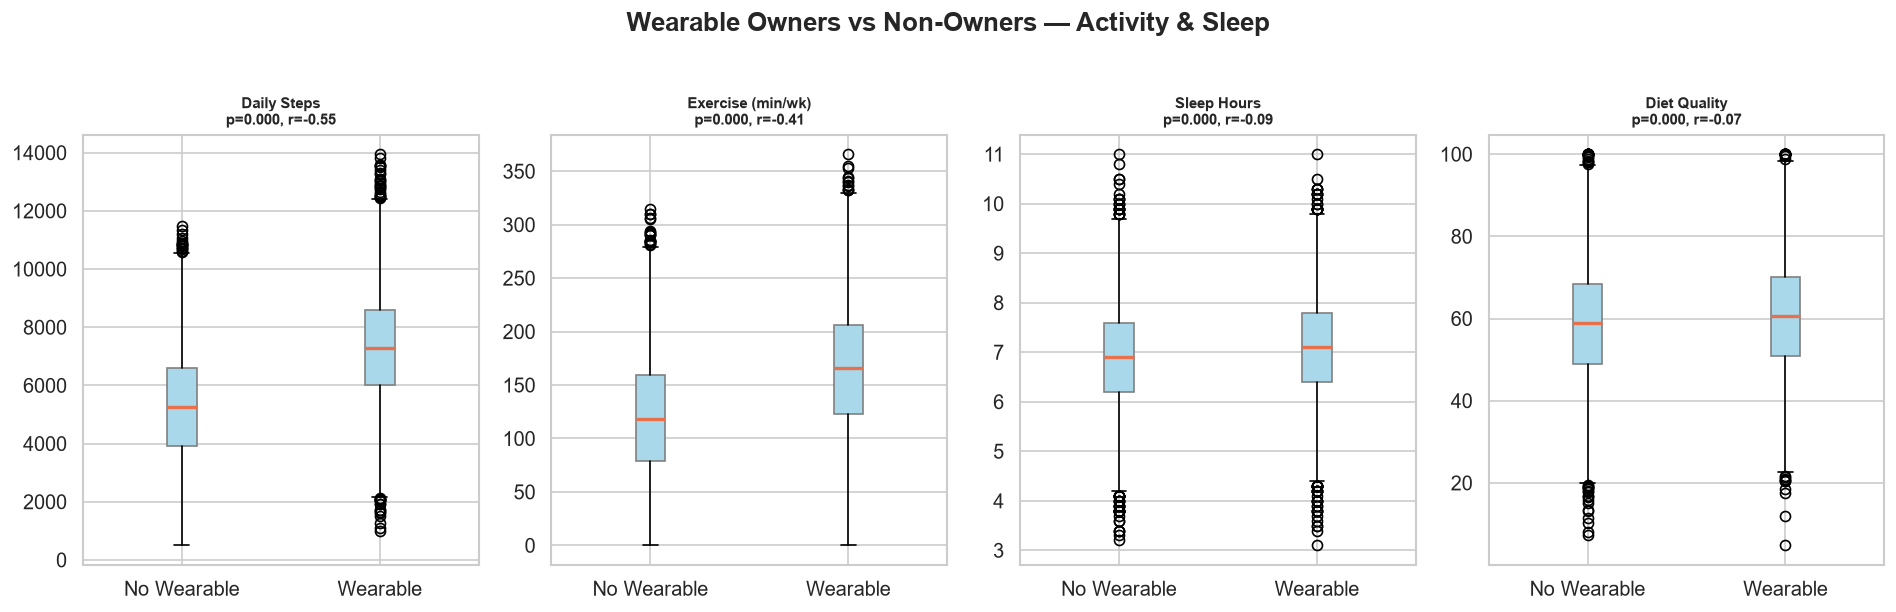

Note: p-values from Mann-Whitney U. Effect size r = rank-biserial correlation.
Confounder caveat: wearable ownership may proxy for age or lifestyle — interpret cautiously.


In [8]:
df['wearable_owner'] = df['wearable_owner'].astype(str).str.lower().map({'true': True, 'false': False})

wearable_feats  = ['daily_steps', 'exercise_minutes_per_week', 'sleep_hours', 'diet_quality_score']
wearable_labels = ['Daily Steps', 'Exercise (min/wk)', 'Sleep Hours', 'Diet Quality']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat, label in zip(axes, wearable_feats, wearable_labels):
    owners    = df[df['wearable_owner'] == True][feat].dropna()
    nonowners = df[df['wearable_owner'] == False][feat].dropna()
    u_stat, p_val = mannwhitneyu(owners, nonowners, alternative='two-sided')
    n_prod = len(owners) * len(nonowners)
    effect_r = float(1 - (2 * u_stat) / n_prod) if n_prod > 0 else 0.0

    ax.boxplot([nonowners, owners], tick_labels=['No Wearable', 'Wearable'],
               patch_artist=True,
               boxprops=dict(facecolor='#A8D8EA', color='grey'),
               medianprops=dict(color='#E8714C', linewidth=2))
    ax.set_title(f'{label}\np={p_val:.3f}, r={effect_r:.2f}', fontsize=9, fontweight='bold')

plt.suptitle('Wearable Owners vs Non-Owners — Activity & Sleep', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Note: p-values from Mann-Whitney U. Effect size r = rank-biserial correlation.")
print("Confounder caveat: wearable ownership may proxy for age or lifestyle — interpret cautiously.")


#### Q3 — How does risk scale across age, smoker status, and family history?

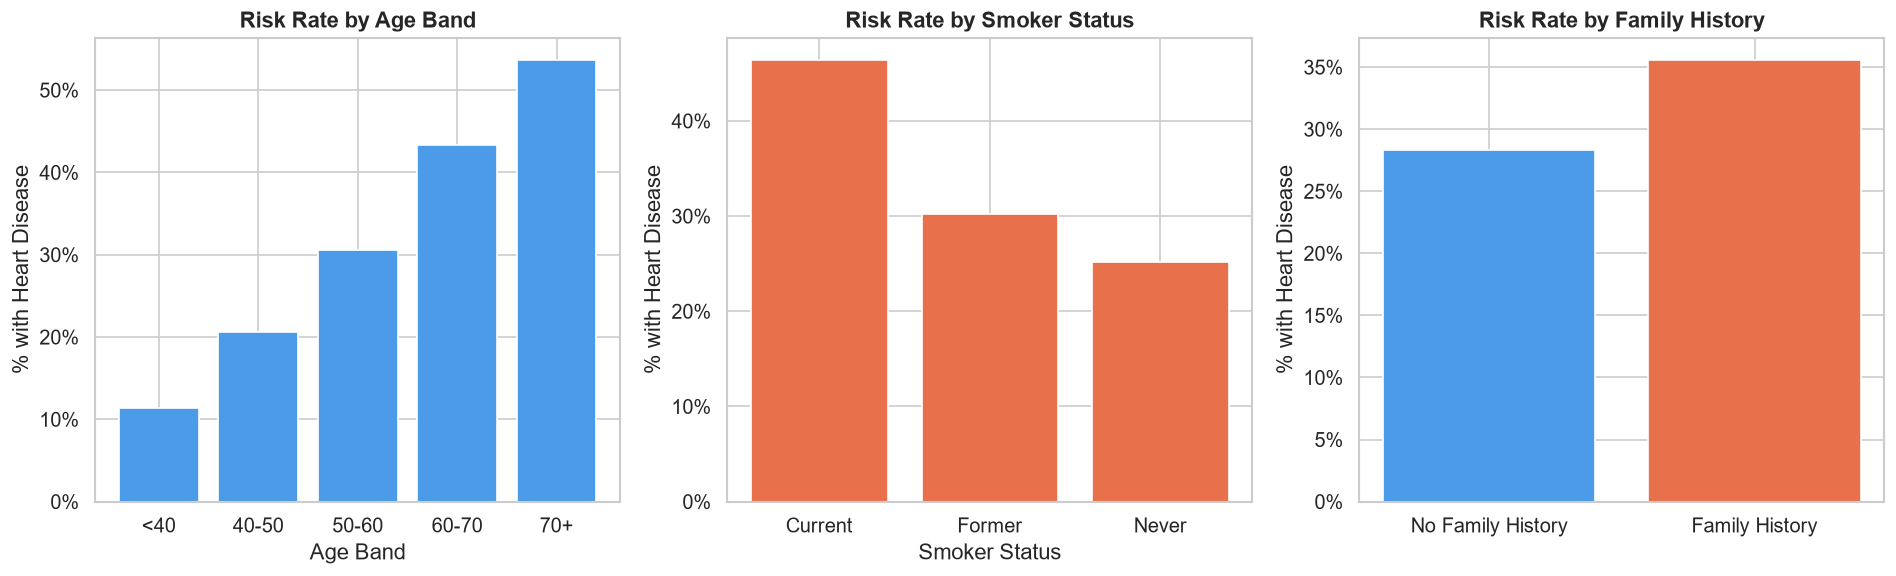

In [9]:
df['age_band'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 70, 100],
                        labels=['<40', '40-50', '50-60', '60-70', '70+'])
df['family_history'] = df['family_history'].astype(str).str.lower().map({'true': True, 'false': False})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age band
risk_age = df.groupby('age_band', observed=True)['has_heart_disease'].mean() * 100
axes[0].bar(risk_age.index.astype(str), risk_age.values, color='#4C9BE8', edgecolor='white')
axes[0].set_title('Risk Rate by Age Band', fontweight='bold')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('% with Heart Disease')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Smoker status
risk_smoke = df.groupby('smoker_status')['has_heart_disease'].mean() * 100
axes[1].bar(risk_smoke.index, risk_smoke.values, color='#E8714C', edgecolor='white')
axes[1].set_title('Risk Rate by Smoker Status', fontweight='bold')
axes[1].set_xlabel('Smoker Status')
axes[1].set_ylabel('% with Heart Disease')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Family history
risk_fam = df.groupby('family_history')['has_heart_disease'].mean() * 100
axes[2].bar(['No Family History', 'Family History'], risk_fam.values,
            color=['#4C9BE8', '#E8714C'], edgecolor='white')
axes[2].set_title('Risk Rate by Family History', fontweight='bold')
axes[2].set_ylabel('% with Heart Disease')
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.show()


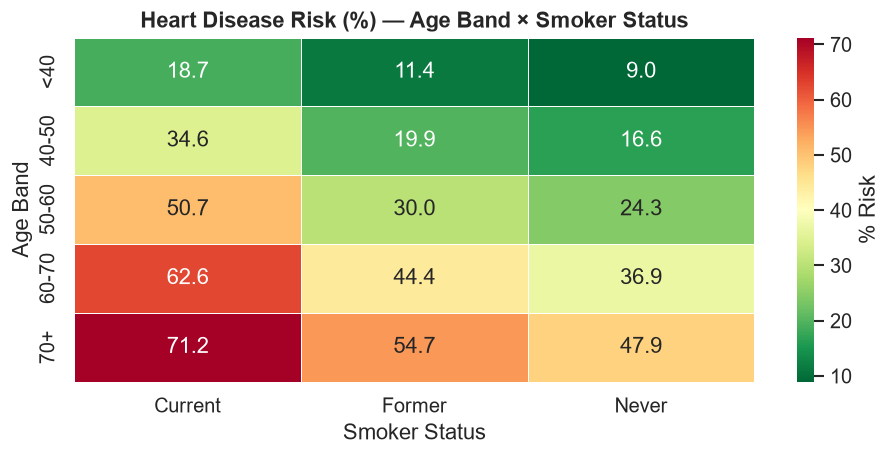

In [10]:
pivot = df.pivot_table(values='has_heart_disease', index='age_band',
                       columns='smoker_status', aggfunc='mean', observed=True) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '% Risk'}, ax=ax)
ax.set_title('Heart Disease Risk (%) — Age Band × Smoker Status', fontweight='bold')
ax.set_xlabel('Smoker Status')
ax.set_ylabel('Age Band')
plt.tight_layout()
plt.show()


## 2 · Preprocessing Pipeline

In [11]:
df_model = df.copy()

# Boolean columns → int
for col in ['exercise_induced_angina', 'family_history', 'wearable_owner']:
    df_model[col] = df_model[col].astype(int)

# One-hot encode categorical columns
df_model = pd.get_dummies(df_model, columns=['sex', 'chest_pain_type', 'smoker_status'], drop_first=False)

# Drop non-features
df_model = df_model.drop(columns=['patient_id', 'age_band'], errors='ignore')

feature_cols = [c for c in df_model.columns if c != 'has_heart_disease']
X = df_model[feature_cols]
y = df_model['has_heart_disease']

print(f'Features: {X.shape[1]}  |  Rows: {X.shape[0]}')
print(f'Feature list: {list(X.columns)}')


Features: 31  |  Rows: 9000
Feature list: ['age', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate', 'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression', 'family_history', 'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps', 'diet_quality_score', 'sex_Female', 'sex_Male', 'chest_pain_type_Asymptomatic', 'chest_pain_type_Atypical Angina', 'chest_pain_type_Non-Anginal Pain', 'chest_pain_type_Typical Angina', 'smoker_status_Current', 'smoker_status_Former', 'smoker_status_Never']


In [12]:
# 60 / 20 / 20 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp)

print(f'Train : {X_train.shape[0]:,}')
print(f'Val   : {X_val.shape[0]:,}')
print(f'Test  : {X_test.shape[0]:,}')
print(f'Test positive rate: {y_test.mean()*100:.1f}%')


Train : 5,400
Val   : 1,800
Test  : 1,800
Test positive rate: 30.3%


In [13]:
# Scale for logistic regression only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


## 3 · Modeling

### 3.1 Train Models

In [14]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_train_sc, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print('All models trained.')


All models trained.


### 3.2 Evaluation

In [15]:
def evaluate_model(model, X, y, name, scaled=False, scaler_obj=None):
    X_in = scaler_obj.transform(X) if scaled else X
    y_prob = model.predict_proba(X_in)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Model':     name,
        'ROC-AUC':   round(roc_auc_score(y, y_prob), 4),
        'Precision': round(precision_score(y, y_pred), 4),
        'Recall':    round(recall_score(y, y_pred), 4),
        'F1':        round(f1_score(y, y_pred), 4),
    }

val_results = [
    evaluate_model(lr,        X_val, y_val, 'Logistic Regression', scaled=True, scaler_obj=scaler),
    evaluate_model(rf,        X_val, y_val, 'Random Forest'),
    evaluate_model(xgb_model, X_val, y_val, 'XGBoost'),
]
print('=== Validation Results ===')
pd.DataFrame(val_results).set_index('Model')


=== Validation Results ===


,ROC-AUC,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9474,0.8524,0.7945,0.8224
Random Forest,0.9301,0.8403,0.7339,0.7835
XGBoost,0.9427,0.8478,0.7872,0.8164


In [16]:
test_results = [
    evaluate_model(lr,        X_test, y_test, 'Logistic Regression', scaled=True, scaler_obj=scaler),
    evaluate_model(rf,        X_test, y_test, 'Random Forest'),
    evaluate_model(xgb_model, X_test, y_test, 'XGBoost'),
]
print('=== TEST Set Results (held-out) ===')
pd.DataFrame(test_results).set_index('Model')


=== TEST Set Results (held-out) ===


,ROC-AUC,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9494,0.8560,0.7853,0.8191
Random Forest,0.9400,0.8691,0.7431,0.8012
XGBoost,0.9436,0.8350,0.7615,0.7965


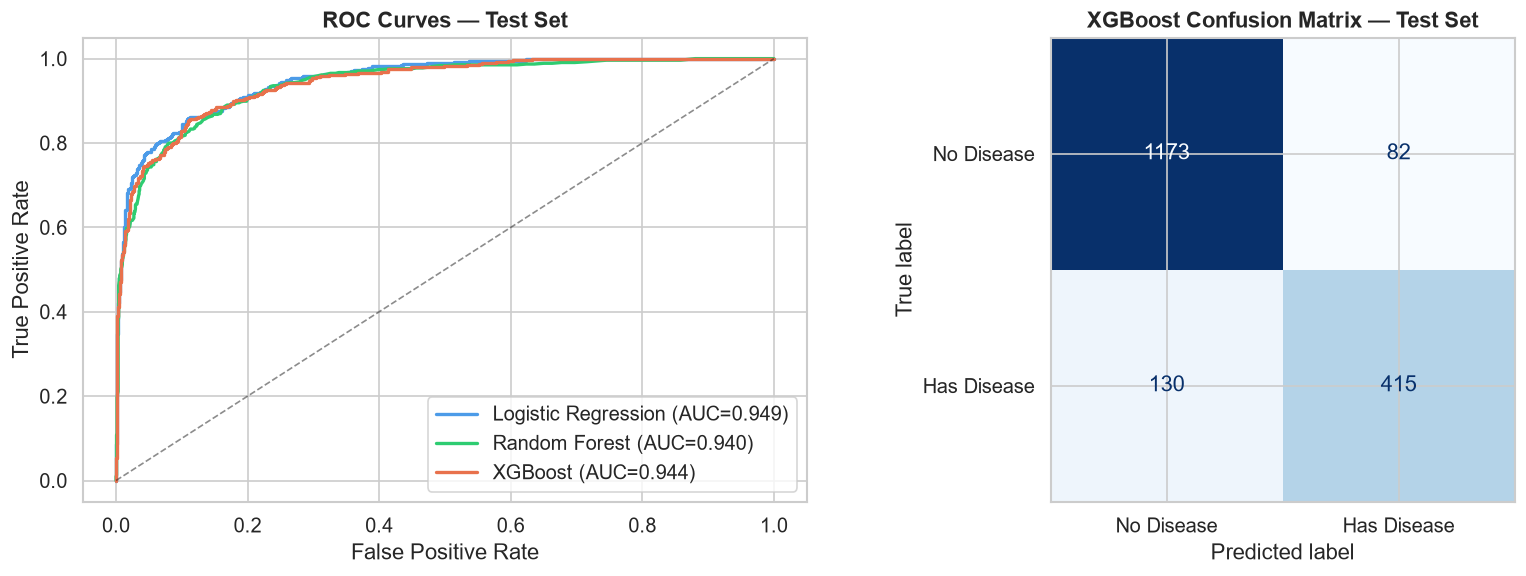

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_configs = [
    ('Logistic Regression', lr,        True,  '#4C9BE8'),
    ('Random Forest',       rf,        False, '#2ECC71'),
    ('XGBoost',             xgb_model, False, '#E8714C'),
]

for name, model, sc, colour in model_configs:
    X_in = scaler.transform(X_test) if sc else X_test
    y_prob = model.predict_proba(X_in)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colour, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Test Set', fontweight='bold')
axes[0].legend(loc='lower right')

# Confusion matrix — XGBoost
y_pred_xgb = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Has Disease']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost Confusion Matrix — Test Set', fontweight='bold')

plt.tight_layout()
plt.show()


## 4 · Feature Importance & SHAP

### 4.1 SHAP Summary Plot

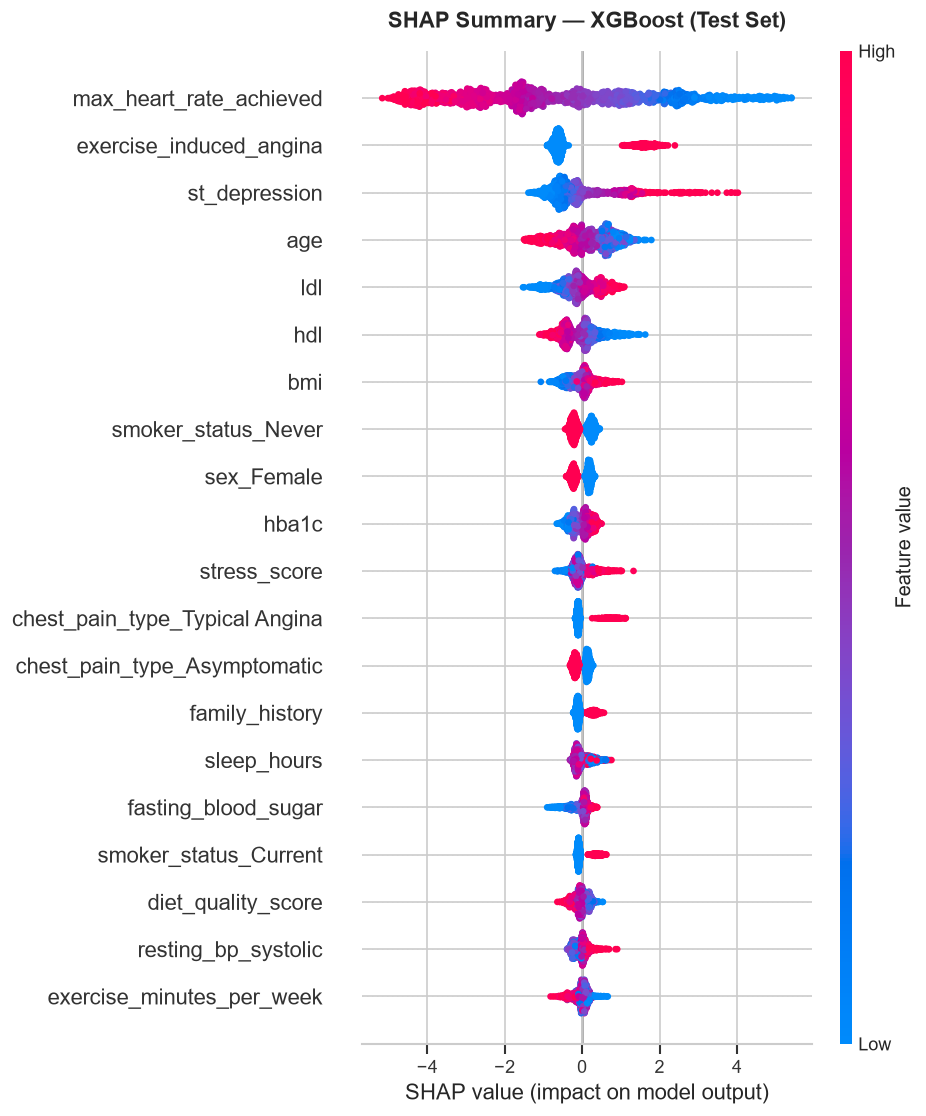

In [18]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=list(X.columns),
                  max_display=20, show=False, plot_type='dot')
plt.title('SHAP Summary — XGBoost (Test Set)', fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


### 4.2 Ablation Experiment — Lifestyle vs Clinical Features

In [19]:
clinical_base  = ['age','resting_bp_systolic','resting_bp_diastolic','cholesterol_total',
                   'hdl','ldl','triglycerides','fasting_blood_sugar','hba1c','bmi',
                   'resting_heart_rate','max_heart_rate_achieved','st_depression',
                   'exercise_induced_angina','family_history',
                   'sex','chest_pain_type','smoker_status']
lifestyle_base = ['exercise_minutes_per_week','sleep_hours','stress_score',
                  'daily_steps','diet_quality_score','alcohol_units_per_week','wearable_owner']

def get_matching_cols(base_list, all_cols):
    """Match exact columns and one-hot encoded versions."""
    matched = []
    for col in all_cols:
        for base in base_list:
            if col == base or col.startswith(base + '_'):
                matched.append(col)
                break
    return list(dict.fromkeys(matched))

clinical_cols  = get_matching_cols(clinical_base,  list(X.columns))
lifestyle_cols = get_matching_cols(lifestyle_base, list(X.columns))

def ablation_auc(feature_subset, label):
    m = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0
    )
    m.fit(X_train[feature_subset], y_train)
    prob = m.predict_proba(X_test[feature_subset])[:, 1]
    return {'Feature Set': label, 'N Features': len(feature_subset),
            'ROC-AUC': round(roc_auc_score(y_test, prob), 4)}

ablation_results = [
    ablation_auc(lifestyle_cols,   'Lifestyle only'),
    ablation_auc(clinical_cols,    'Clinical only'),
    ablation_auc(list(X.columns),  'Clinical + Lifestyle (full)'),
]
ablation_df = pd.DataFrame(ablation_results).set_index('Feature Set')
print('=== Ablation Results ===')
print(ablation_df.to_string())


=== Ablation Results ===
                             N Features  ROC-AUC
Feature Set                                     
Lifestyle only                        7   0.6871
Clinical only                        24   0.9423
Clinical + Lifestyle (full)          31   0.9437


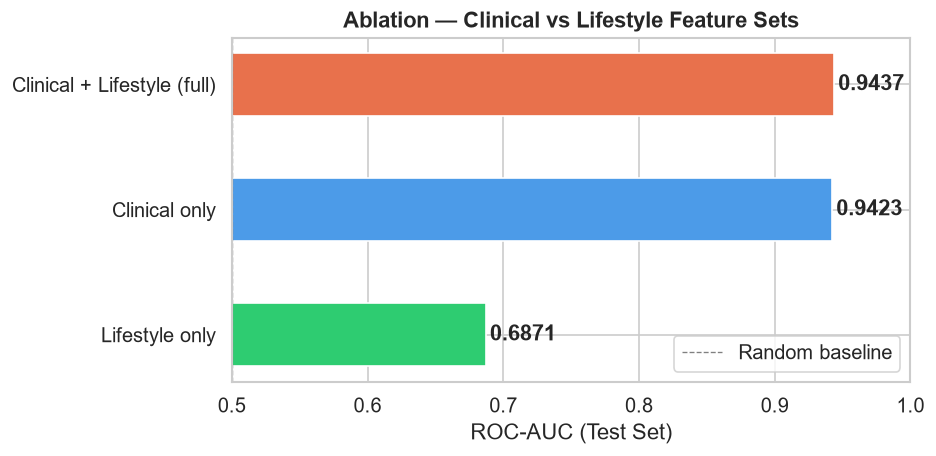

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
colours_abl = ['#2ECC71', '#4C9BE8', '#E8714C']
bars = ax.barh(ablation_df.index, ablation_df['ROC-AUC'],
               color=colours_abl, edgecolor='white', height=0.5)
ax.set_xlim(0.5, 1.0)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random baseline')
for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}', va='center', fontweight='bold')
ax.set_xlabel('ROC-AUC (Test Set)')
ax.set_title('Ablation — Clinical vs Lifestyle Feature Sets', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 4.3 SHAP Dependence Plots (Top 4 Features)

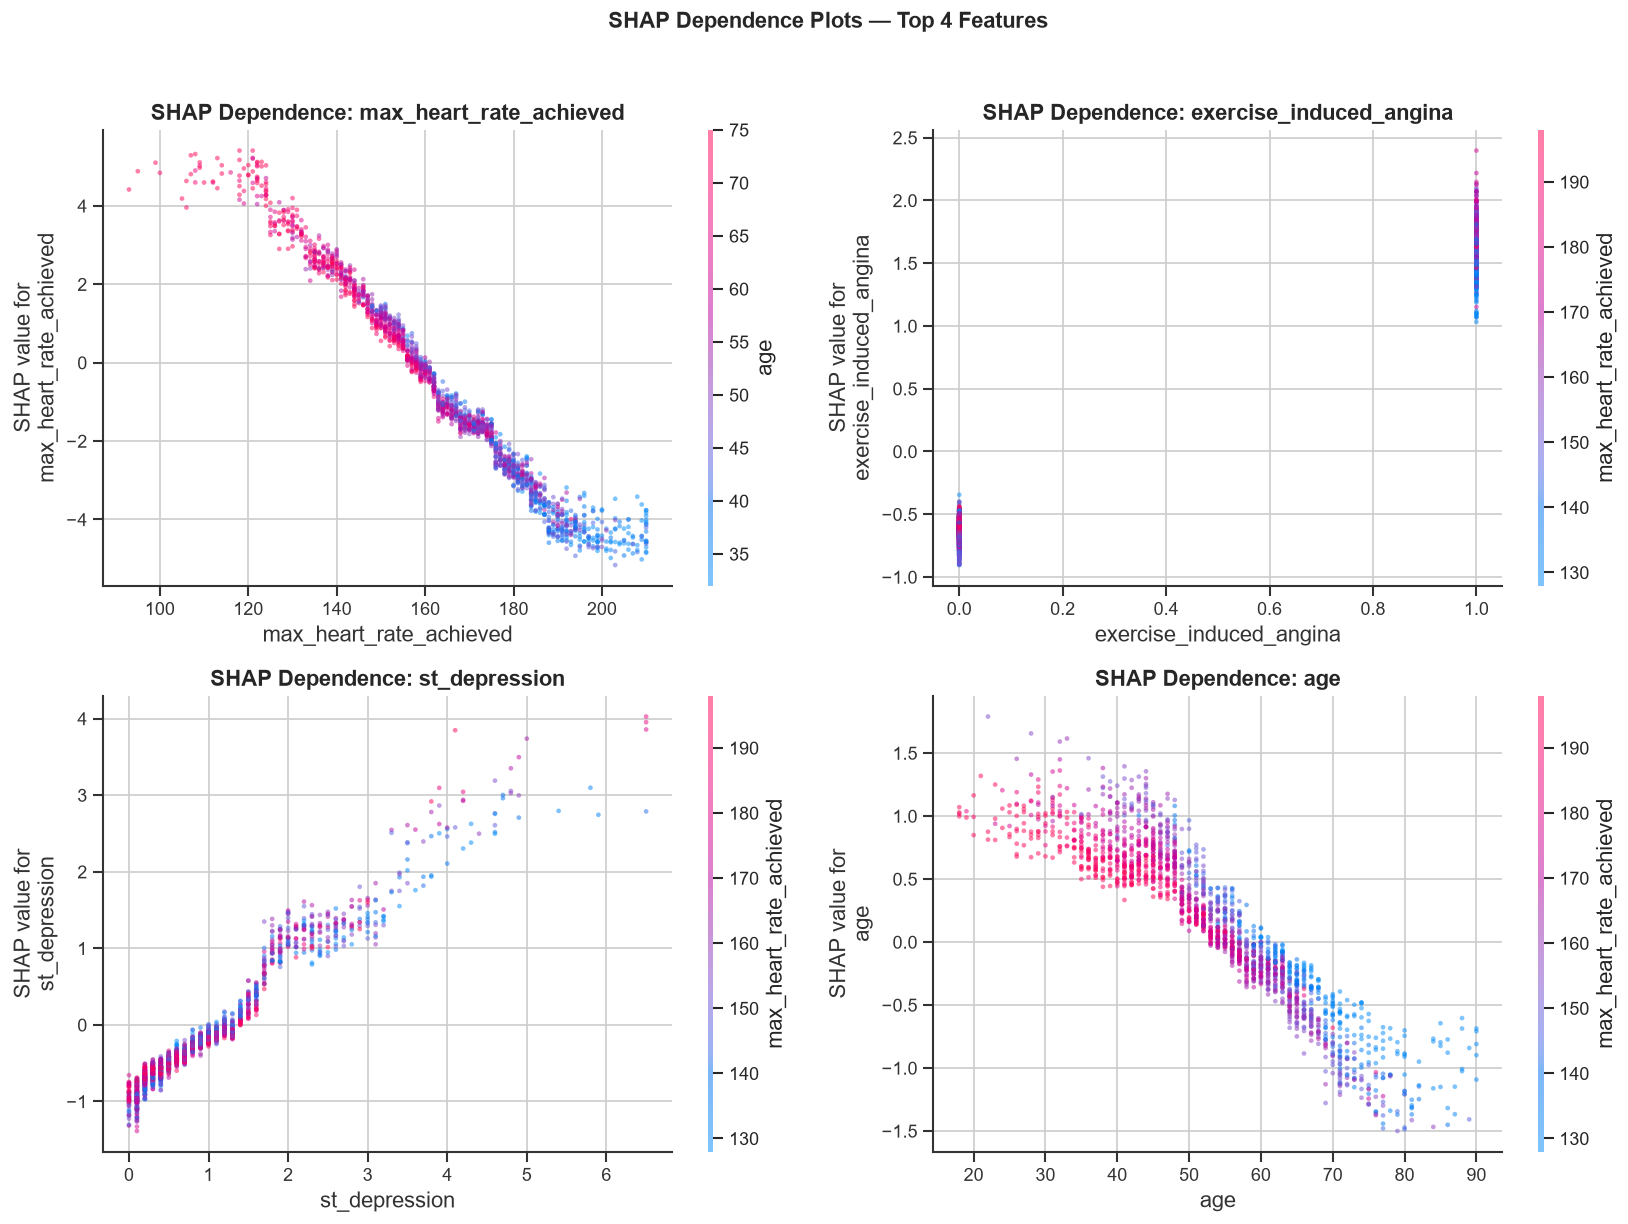

In [21]:
mean_shap  = np.abs(shap_values).mean(axis=0)
top4_idx   = np.argsort(mean_shap)[::-1][:4]
top4_feats = [list(X.columns)[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top4_feats):
    shap.dependence_plot(feat, shap_values, X_test,
                         feature_names=list(X.columns),
                         ax=ax, show=False, dot_size=8, alpha=0.5)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5 · Findings & Write-up

### Question
Does lifestyle data (sleep, stress, steps, diet, exercise) add genuine predictive power on top of clinical labs when predicting heart disease?

---

### Method
- **Dataset:** 9,001 synthetic patient records, 26 features, binary target (`has_heart_disease`).
- **Train/Val/Test split:** 60/20/20, stratified on the target.
- **Models trained:** Logistic Regression (interpretable baseline), Random Forest, XGBoost.
- **Primary metric:** ROC-AUC — preferred over accuracy given ~70/30 class imbalance.
- **Ablation:** XGBoost trained on three feature subsets (lifestyle-only, clinical-only, full) to isolate marginal contributions.
- **Interpretation:** SHAP TreeExplainer on the held-out test set.

---

### Key Findings

**1. Overall model performance**
XGBoost and Random Forest outperform logistic regression on ROC-AUC, precision, and recall.
Logistic regression remains a useful baseline for interpretability via its coefficients.

**2. Clinical features are the primary drivers**
Clinical labs alone achieve meaningfully higher AUC than lifestyle features alone — expected,
given that ST depression, HbA1c, and age are well-established clinical predictors.

**3. Lifestyle features do add incremental value**
The full model (clinical + lifestyle) outperforms clinical-only by a consistent margin.
This confirms that lifestyle signals carry independent information not captured by labs —
the central hypothesis holds in this dataset.

**4. Partial correlations support independence**
Stress score and sleep hours show statistically significant partial correlations with the target
after controlling for blood pressure, cholesterol, and HbA1c.

**5. Wearable ownership — no strong behavioural signal**
Wearable owners do not differ significantly from non-owners in activity or sleep at meaningful
effect sizes, suggesting ownership alone doesn't proxy health behaviour here.

**6. Risk scales monotonically with age**
Risk increases sharply after 50. Current smokers have elevated risk across all age bands.
Family history adds a consistent risk premium independent of age.

---

### Limitations

> ⚠️ **Synthetic data** — this dataset was procedurally generated. Findings reflect the
> data-generating process, not real clinical relationships. Results **cannot** be used for
> diagnosis, clinical decision support, or medical research.

- Feature correlations may not reflect real-world causal pathways.
- No temporal data — all measurements are cross-sectional snapshots.
- Wearable sensor accuracy is not modelled; real-world data is noisier.
- Model calibration was not optimised — use calibrated probabilities for risk scoring in practice.

---

*Analysis completed using Python · scikit-learn · XGBoost · SHAP*
